In [1]:
!pip install -q "transformers>=4.40.0" accelerate datasets pillow qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 66.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/RL/RL_Scene_Graphs
%ls

/content/drive/MyDrive/RL/RL_Scene_Graphs
datasets/  Image_Data_Prep.ipynb  mllm_generation.py     __pycache__/
grpo-run/  MLLM_Eval.ipynb        MLLM_Pipeline.ipynb
grpo-sgg/  mllm_eval.py           MLLM_Train_GRPO.ipynb


### Dataset and Prompt

In [4]:
from datasets import load_from_disk
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
import torch
import re
import json
from typing import Tuple, Any, Dict
from PIL import Image
import matplotlib.pyplot as plt
from pprint import pprint


In [5]:
def load_sample(ds, index: int = 0):
    """Load a VG sample from a HuggingFace-disk dataset.
    """
    sample = ds[index]
    return {
        "image": sample["image"].convert("RGB"),
        "objects": sample["objects"],
        "relationships": sample["relationships"],
        "prompt_open": sample.get("prompt_open", ""),
        "prompt_close": sample.get("prompt_close", "")
    }

def build_messages(image, prompt: str, system_prompt=None):
    """Build the chat-style message list the Qwen2-VL processor expects.

    This mirrors the repository: the user message contains an image entry and a text entry.
    """

    sys_prompt = system_prompt if system_prompt else "You are a helpful assistant"

    return [
        {
            "role": "system",
            "content": sys_prompt
        },
         {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

In [6]:
vg_val = load_from_disk("./datasets/vg150_val_sgg_prompt")
psg_val = load_from_disk("./datasets/psg_test_sg")

print(vg_val)
print(psg_val)

Dataset({
    features: ['image_id', 'image', 'prompt_open', 'prompt_close', 'objects', 'relationships'],
    num_rows: 5000
})
Dataset({
    features: ['image_id', 'image', 'objects', 'relationships'],
    num_rows: 2186
})


{'image': <PIL.Image.Image image mode=RGB size=640x464 at 0x788050C4B800>,
 'objects': '[{"id": "person.1", "bbox": [3, 199, 234, 419]}, {"id": '
            '"person.2", "bbox": [190, 3, 474, 391]}, {"id": "person.3", '
            '"bbox": [0, 142, 51, 238]}, {"id": "person.4", "bbox": [546, 56, '
            '640, 295]}, {"id": "banana.5", "bbox": [604, 384, 640, 456]}, '
            '{"id": "banana.6", "bbox": [536, 396, 639, 464]}, {"id": '
            '"banana.7", "bbox": [562, 401, 627, 448]}, {"id": "banana.8", '
            '"bbox": [499, 324, 573, 381]}, {"id": "banana.9", "bbox": [594, '
            '358, 640, 388]}, {"id": "apple.10", "bbox": [426, 397, 461, '
            '425]}, {"id": "apple.11", "bbox": [424, 370, 460, 391]}, {"id": '
            '"apple.12", "bbox": [305, 408, 343, 449]}, {"id": "apple.13", '
            '"bbox": [390, 384, 429, 417]}, {"id": "apple.14", "bbox": [447, '
            '371, 497, 405]}, {"id": "apple.15", "bbox": [356, 399, 381, '
         

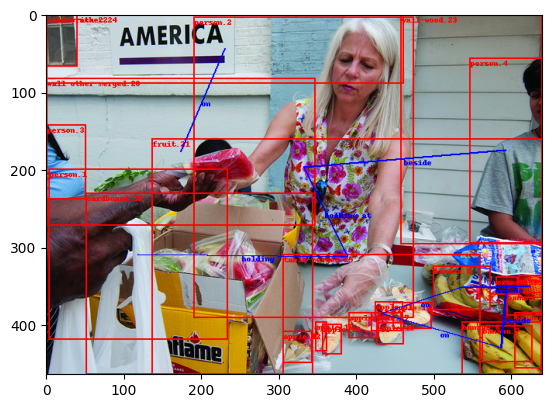

In [7]:
## sample the psg dataset
sample_psg = load_sample(psg_val, index=1)
pprint(sample_psg)
plt.imshow(sample_psg["image"])
plt.show()

{'image': <PIL.Image.Image image mode=RGB size=500x375 at 0x788050C55C40>, 'objects': '[{"id": "table.1", "bbox": [0, 0, 444, 374]}, {"id": "plate.2", "bbox": [76, 16, 434, 363]}, {"id": "glass.3", "bbox": [392, 0, 498, 145]}, {"id": "fruit.4", "bbox": [151, 73, 269, 157]}, {"id": "tail.5", "bbox": [311, 117, 343, 143]}, {"id": "orange.6", "bbox": [200, 95, 262, 142]}]', 'relationships': '[{"subject": "fruit.4", "predicate": "on", "object": "plate.2"}, {"subject": "plate.2", "predicate": "on", "object": "table.1"}, {"subject": "orange.6", "predicate": "on", "object": "plate.2"}]', 'prompt_open': 'Generate a structured scene graph for an image of size (500 x 375) using the following format:\n\n<answer>\n{\n  "objects": [\n    {"id": "object_name.number", "bbox": [x1, y1, x2, y2]},\n    ...\n  ],\n  "relationships": [\n    {"subject": "object_name.number", "predicate": "relationship_type", "object": "object_name.number"},\n    ...\n  ]\n}\n</answer>\n\n### **Guidelines:**\n- **Objects:**

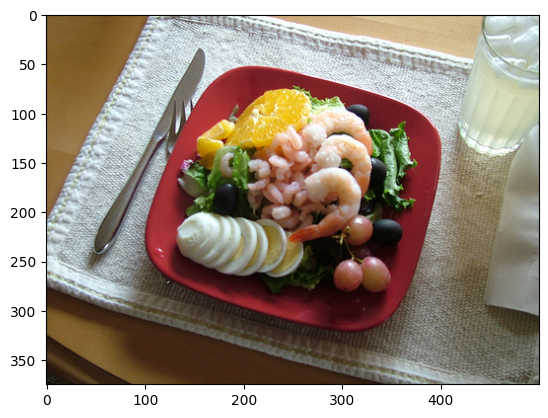

In [8]:
sample = load_sample(vg_val, index=80)
print(sample)
plt.imshow(sample["image"])
plt.show()

In [9]:
print("==OBJECTS==")
print(sample["objects"])
print("==RELATIONSHIPS==")
print(sample["relationships"])

print("==PROMPT OPEN==")
print(sample["prompt_open"])
print("==PROMPT CLOSE==")
print(sample["prompt_close"])

==OBJECTS==
[{"id": "table.1", "bbox": [0, 0, 444, 374]}, {"id": "plate.2", "bbox": [76, 16, 434, 363]}, {"id": "glass.3", "bbox": [392, 0, 498, 145]}, {"id": "fruit.4", "bbox": [151, 73, 269, 157]}, {"id": "tail.5", "bbox": [311, 117, 343, 143]}, {"id": "orange.6", "bbox": [200, 95, 262, 142]}]
==RELATIONSHIPS==
[{"subject": "fruit.4", "predicate": "on", "object": "plate.2"}, {"subject": "plate.2", "predicate": "on", "object": "table.1"}, {"subject": "orange.6", "predicate": "on", "object": "plate.2"}]
==PROMPT OPEN==
Generate a structured scene graph for an image of size (500 x 375) using the following format:

<answer>
{
  "objects": [
    {"id": "object_name.number", "bbox": [x1, y1, x2, y2]},
    ...
  ],
  "relationships": [
    {"subject": "object_name.number", "predicate": "relationship_type", "object": "object_name.number"},
    ...
  ]
}
</answer>

### **Guidelines:**
- **Objects:**
  - Assign a unique ID for each object using the format `"object_name.number"` (e.g., `"person

#### Building inputs


In [10]:
def build_inputs(processor: AutoProcessor, messages, device: torch.device):
    """Convert chat messages + images into model-ready tensors.

    Steps:
    1. Convert messages into a single chat text via `apply_chat_template`.
    2. Extract vision tensors via `process_vision_info`.
    3. Call `processor(...)` with text, images, videos to get tensors.
    """
    # Apply chat template to turn the messages into the expected prompt string
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # process_vision_info (from qwen_vl_utils) turns the messages image(s) into tensors
    image_inputs, video_inputs = process_vision_info(messages)

    print("IMAGE INPUTS")
    print(image_inputs)

    # Build model inputs (text + image tensors)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    # Move tensors to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    return inputs, text

### Model

In [16]:
# model_name = "Qwen/Qwen2-VL-2B-Instruct"
# model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
model_name = "Qwen/Qwen2.5-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(model_name)
# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     model_name,
#     torch_dtype="auto",
#     device_map="auto"
# )

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("DEVICE = ", model.device)
model.eval()




preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

DEVICE =  cuda:0


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

#### Generation

In [51]:
def extract_answer_content(text: str) -> str:
    """Extract JSON content from model output: first try <answer>...</answer>, then code fences."""
    # clean up simple markdown fences
    text = text.replace("```", " ")
    m = re.search(r"<answer>(.*?)</answer>", text, re.S)
    if m:
        return m.group(1).strip()
    m = re.search(r"\{.*\}", text, re.S)
    return m.group(0).strip() if m else text


def generate_and_parse(model: Qwen2VLForConditionalGeneration, processor: AutoProcessor, inputs: Dict[str, torch.Tensor], max_new_tokens: int = 2048) -> Any:
    """Run generation and parse the scene-graph JSON from the generated text.

    The repository trims prompt tokens and decodes only the generated suffix. We follow
    the same approach: for each batch element, remove the input prompt length.
    """
    model.eval()
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.4,
            top_k=5,
            top_p=0.001,
            repetition_penalty=1.0,
            do_sample=True,
        )

    # Trim prompt tokens: generated_ids is [batch, seq], inputs['input_ids'] is the prompt
    input_ids = inputs.get("input_ids")
    if input_ids is None:
        # Fallback: decode whole generated sequence
        decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)
        text = decoded[0]
    else:
        # Trim the prompt portion from each sequence
        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(input_ids, generated_ids)]
        text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    # Extract JSON-like answer and parse
    json_text = extract_answer_content(text)
    try:
        return json.loads(json_text)
    except Exception:
        # if parsing fails, return raw text and the extracted fragment for debugging
        return {"_raw_text": text, "_extracted": json_text}

In [24]:
# ---------- Build messages, inputs ----------
# experimenting
SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant "
    "first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning "
    "process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., "
    "<think> reasoning process here </think><answer> answer here </answer>"
)

custom_prompt = """
Please identify the number of entites in this image, naming them person.1, person.2, etc..
Also identify the relationships. Example person standing on road

### **Output Format:**
<answer>
{
  "objects": [
    {"id": "object_name.number", "bbox": [x1, y1, x2, y2]},
    ...
  ],
  "relationships": [
    {"subject": "object_name.number", "predicate": "relationship_type", "object": "object_name.number"},
    ...
  ]
}
</answer>
Now output this JSON for the given Image:
"""

prompt = sample["prompt_close"]


messages = build_messages(sample["image"], prompt, system_prompt=SYSTEM_PROMPT)
inputs, prompt_text = build_inputs(processor, messages, model.device)

print("===MESSAGES===")
print(messages)
print("===PROMPT TEXT===")
print(prompt_text)

IMAGE INPUTS
[<PIL.Image.Image image mode=RGB size=504x364 at 0x787FCAD3B9E0>]
===MESSAGES===
[{'role': 'system', 'content': 'A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., <think> reasoning process here </think><answer> answer here </answer>'}, {'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=500x375 at 0x788050C55C40>}, {'type': 'text', 'text': 'Generate a structured scene graph for an image of size (500 x 375) using the specified object and relationship categories.\n\n### **Output Format:**\n<answer>\n{\n  "objects": [\n    {"id": "object_name.number", "bbox": [x1, y1, x2, y2]},\n    ...\n  ],\n  "relationships": [\n    {"subject": "object_name.number", "predicate

In [25]:
inputs

{'input_ids': tensor([[151644,   8948,    198,  ..., 151644,  77091,    198]],
        device='cuda:0'),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'),
 'pixel_values': tensor([[ 0.0179,  0.0471,  0.0617,  ..., -0.8119, -0.8403, -0.8403],
         [ 0.0617,  0.0325,  0.0617,  ..., -0.9256, -0.8830, -0.8830],
         [ 0.0909,  0.0909,  0.0909,  ..., -0.7834, -0.7550, -0.8261],
         ...,
         [-0.2740, -0.5076, -0.4784,  ...,  0.0840,  0.0840,  0.0840],
         [-0.2010, -0.3324, -0.2302,  ...,  0.0698,  0.1266,  0.0271],
         [ 0.0033,  0.0617,  0.0179,  ..., -0.2715, -0.4706, -0.5559]],
        device='cuda:0'),
 'image_grid_thw': tensor([[ 1, 26, 36]], device='cuda:0')}

In [20]:
# ---------- Generate and parse JSON scene graph ----------
scene_graph = generate_and_parse(model, processor, inputs)

pprint(scene_graph)

{'objects': [{'bbox': [99, 50, 405, 314], 'id': 'plate.1'},
             {'bbox': [45, 33, 164, 239], 'id': 'knife.1'},
             {'bbox': [422, 0, 504, 141], 'id': 'glass.1'},
             {'bbox': [446, 108, 504, 298], 'id': 'napkin.1'},
             {'bbox': [135, 71, 378, 275], 'id': 'salad.1'}],
 'relationships': [{'object': 'salad.1',
                    'predicate': 'holding',
                    'subject': 'plate.1'},
                   {'object': 'plate.1',
                    'predicate': 'next to',
                    'subject': 'knife.1'},
                   {'object': 'plate.1',
                    'predicate': 'next to',
                    'subject': 'glass.1'},
                   {'object': 'plate.1',
                    'predicate': 'next to',
                    'subject': 'napkin.1'}]}


In [49]:
# make function to generate a scene graph given a sample and model
def generate_pipeline(sample, model, processor, sys_prompt=None):
  prompt = sample["prompt_close"]

  messages = build_messages(sample["image"], prompt, system_prompt=sys_prompt)
  inputs, prompt_text = build_inputs(processor, messages, model.device)

  scene_graph = generate_and_parse(model, processor, inputs)
  return scene_graph


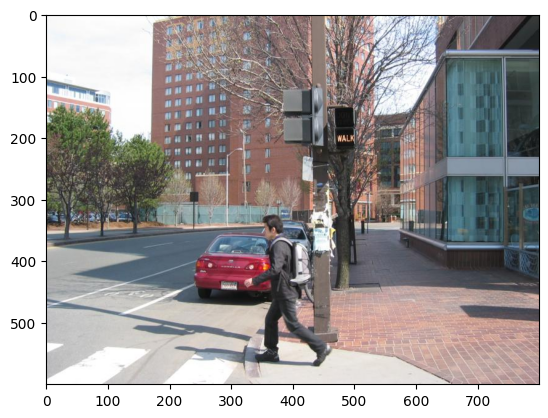

[{'bbox': [318, 345, 796, 598], 'id': 'sidewalk.1'},
 {'bbox': [567, 0, 796, 414], 'id': 'building.2'},
 {'bbox': [168, 0, 427, 319], 'id': 'building.3'},
 {'bbox': [319, 322, 461, 568], 'id': 'man.4'},
 {'bbox': [421, 0, 470, 533], 'id': 'pole.5'},
 {'bbox': [646, 66, 741, 232], 'id': 'window.6'},
 {'bbox': [237, 351, 364, 460], 'id': 'car.7'},
 {'bbox': [0, 144, 89, 364], 'id': 'tree.8'},
 {'bbox': [100, 192, 207, 354], 'id': 'tree.9'},
 {'bbox': [56, 153, 118, 358], 'id': 'tree.10'},
 {'bbox': [642, 260, 741, 371], 'id': 'window.11'},
 {'bbox': [744, 68, 797, 230], 'id': 'window.12'},
 {'bbox': [348, 335, 429, 396], 'id': 'car.13'},
 {'bbox': [747, 261, 796, 368], 'id': 'window.14'},
 {'bbox': [629, 71, 648, 242], 'id': 'window.15'},
 {'bbox': [415, 403, 463, 466], 'id': 'bike.16'}]
[{'object': 'window.6', 'predicate': 'has', 'subject': 'building.2'},
 {'object': 'window.12', 'predicate': 'has', 'subject': 'building.2'},
 {'object': 'window.11', 'predicate': 'has', 'subject': 'build

In [46]:
import ast

sample = load_sample(vg_val, index=1)
plt.imshow(sample["image"])
plt.show()
pprint(ast.literal_eval(sample["objects"]))
pprint(ast.literal_eval(sample["relationships"]))

In [52]:
result = generate_pipeline(sample, model, processor, sys_prompt=SYSTEM_PROMPT)
pprint(result)

IMAGE INPUTS
[<PIL.Image.Image image mode=RGB size=812x588 at 0x787FC96F8D10>]
{'objects': [{'bbox': [320, 318, 470, 562], 'id': 'person.1'},
             {'bbox': [243, 347, 437, 455], 'id': 'car.1'},
             {'bbox': [175, 0, 543, 330], 'id': 'building.1'},
             {'bbox': [578, 0, 812, 408], 'id': 'building.2'},
             {'bbox': [298, 330, 812, 588], 'id': 'sidewalk.1'},
             {'bbox': [0, 330, 578, 588], 'id': 'street.1'},
             {'bbox': [0, 148, 114, 360], 'id': 'tree.1'},
             {'bbox': [79, 194, 214, 350], 'id': 'tree.2'},
             {'bbox': [248, 260, 300, 337], 'id': 'tree.3'},
             {'bbox': [344, 262, 385, 337], 'id': 'tree.4'},
             {'bbox': [385, 255, 427, 337], 'id': 'tree.5'},
             {'bbox': [427, 255, 465, 337], 'id': 'tree.6'},
             {'bbox': [465, 0, 668, 438], 'id': 'tree.7'},
             {'bbox': [390, 117, 462, 213], 'id': 'traffic_light.1'},
             {'bbox': [469, 146, 514, 218], 'id': 'tra